# Milestone 1: Exploratory Data Analysis

## Last.fm UK User Graph Dataset

This notebook is the full Milestone 1 deliverable for:

- exploratory data analysis
- preprocessing of the chosen dataset
- basic statistics and deeper insights

It is intentionally over-complete: beyond simple descriptive statistics, it also connects the analysis to the actual project vision, which is the value of **second-degree connections** in a social graph.

## Project framing

The project is not just about showing a network. The real question is:

> how much opportunity exists one hop beyond a user's direct friends, and how meaningful are those second-degree connections once we filter them by shared attributes?

The available local files support this directly for:

- shared country
- shared age group

Important caveat:

The local workspace does **not** include a user-to-artist listening table, so user-level music-taste matching cannot be computed honestly from the files currently available. Artist and tag metadata are still analyzed as context, but not used to fake user-level taste similarity.

In [1]:
%matplotlib inline

import json
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".mplconfig"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from music_data_utils import (
    compute_degree_table,
    load_artists,
    load_network,
    load_tags,
    load_users,
)
from second_degree_utils import add_user_matching_features

plt.style.use("seaborn-v0_8-whitegrid")

ROOT = Path.cwd()
summary_path = ROOT / "milestone1" / "data" / "milestone1_summary.json"
summary = json.loads(summary_path.read_text(encoding="utf-8"))

## 1. Data loading

We load the raw files and immediately turn them into analysis-friendly tables:

- `UsersData_anonymized`: cleaned demographics and profile fields
- `network`: deduplicated undirected friendship graph
- `Tags`: global tag vocabulary and counts
- `ArtistsMap`: artist identifiers and names

The friend-of-friend metrics are precomputed in the milestone summary export because full two-hop expansion over the whole graph is expensive, but still based on the same raw files.

In [2]:
users = add_user_matching_features(load_users(ROOT))
network_raw = load_network(ROOT, deduplicate=False)
network_unique = load_network(ROOT, deduplicate=True)
tags = load_tags(ROOT)
artists = load_artists(ROOT)
degree_table = compute_degree_table(network_unique)

users = users.merge(degree_table, on="user_id", how="left")
users["degree"] = users["degree"].fillna(0).astype("int64")

file_inventory = pd.DataFrame(
    [
        {"file": "UsersData_anonymized", "rows": len(users), "size_mb": round((ROOT / "UsersData_anonymized").stat().st_size / 1_048_576, 2)},
        {"file": "network (raw rows)", "rows": len(network_raw), "size_mb": round((ROOT / "network").stat().st_size / 1_048_576, 2)},
        {"file": "network (unique undirected)", "rows": len(network_unique), "size_mb": round((ROOT / "network").stat().st_size / 1_048_576, 2)},
        {"file": "Tags", "rows": len(tags), "size_mb": round((ROOT / "Tags").stat().st_size / 1_048_576, 2)},
        {"file": "ArtistsMap", "rows": len(artists), "size_mb": round((ROOT / "ArtistsMap").stat().st_size / 1_048_576, 2)},
    ]
)

display(file_inventory)

,file,rows,size_mb
0,UsersData_anonymized,76778,2.23
1,network (raw rows),832344,9.35
2,network (unique undirected),389639,9.35
3,Tags,181325,1.88
4,ArtistsMap,253422,13.67


## 2. Preprocessing decisions

The raw files are fairly clean, but there are still important preprocessing steps:

- treat `age = -1` as missing
- restrict ages to a plausible range and derive age groups
- treat `playcount = -1` as missing
- normalize country and gender labels
- combine day, month, and year into a registration date
- remove self-loops and duplicate/reciprocal friendship edges
- keep tags normalized, but avoid claiming user-level music taste without user listening data

In [3]:
quality_checks = pd.DataFrame(
    {
        "metric": [
            "raw_users",
            "connected_users",
            "users_with_degree_zero",
            "missing_age_markers",
            "usable_age_values",
            "missing_country",
            "missing_gender",
            "raw_friendship_rows",
            "unique_friendships",
            "duplicate_or_reciprocal_ratio",
            "blank_cleaned_global_tags",
        ],
        "value": [
            len(users),
            int(users["degree"].gt(0).sum()),
            int(users["degree"].eq(0).sum()),
            int(users["age_raw"].eq(-1).sum()),
            int(users["age_clean"].notna().sum()),
            int(users["country"].isna().sum()),
            int(users["gender"].isna().sum()),
            len(network_raw),
            len(network_unique),
            round(1 - (len(network_unique) / len(network_raw)), 4),
            int(tags["tag"].isna().sum()),
        ],
    }
)

display(quality_checks)

,metric,value
0,raw_users,76778.0000
1,connected_users,75969.0000
2,users_with_degree_zero,809.0000
3,missing_age_markers,14456.0000
4,usable_age_values,61826.0000
5,missing_country,9.0000
6,missing_gender,277.0000
7,raw_friendship_rows,832344.0000
8,unique_friendships,389639.0000
9,duplicate_or_reciprocal_ratio,0.5319


## 3. Basic descriptive statistics

In [4]:
overview = pd.DataFrame(
    [
        {"metric": "users", "value": len(users)},
        {"metric": "connected users", "value": int(users["degree"].gt(0).sum())},
        {"metric": "unique undirected friendships", "value": len(network_unique)},
        {"metric": "artists", "value": len(artists)},
        {"metric": "global tags", "value": len(tags)},
        {"metric": "median direct-friend degree", "value": int(users["degree"].median())},
        {"metric": "median second-degree count", "value": summary["overview"]["median_second_degree"]},
    ]
)

user_stats = users[["age_clean", "playcount", "degree"]].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]
).T

display(overview)
display(user_stats)

,metric,value
0,users,76778
1,connected users,75969
2,unique undirected friendships,389639
3,artists,253422
4,global tags,181325
5,median direct-friend degree,5
6,median second-degree count,166


,count,mean,std,min,25%,50%,75%,90%,99%,max
age_clean,61826.0,25.11424,7.217885,10.0,21.0,23.0,27.0,34.0,51.0,90.0
playcount,76742.0,30908.546506,36918.708785,0.0,7292.0,20096.0,41780.5,71450.2,164921.45,1000108.0
degree,76778.0,10.149756,22.695751,0.0,2.0,5.0,11.0,22.0,80.0,2013.0


In [5]:
print("Key insights from the precomputed second-degree analysis:")
for idx, insight in enumerate(summary["insights"], start=1):
    print(f"{idx}. {insight}")

Key insights from the precomputed second-degree analysis:
1. The cleaned graph contains 389,639 unique undirected friendships across 75,969 connected users.
2. The median user has 5 direct friends but 166 second-degree candidates, which supports the core idea that the real opportunity lies beyond the first hop.
3. Second-degree opportunity scales quickly: the 90th percentile user reaches 1,542 friends-of-friends after excluding direct ties.
4. Attribute overlap remains meaningful in the second-degree layer: the median user has 43 second-degree candidates sharing both country and age group.
5. The dataset is overwhelmingly UK-based, so country matching is informative for prototype logic but should not be over-interpreted as geographic diversity.


## 4. User demographics

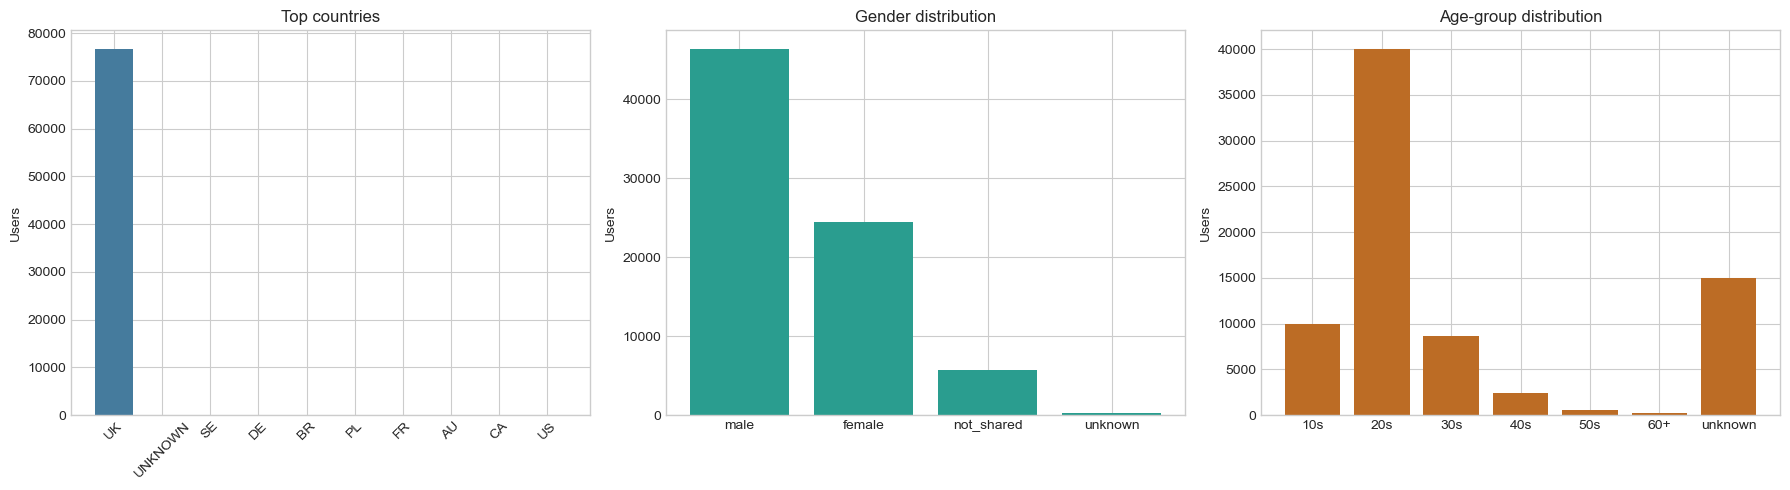

In [6]:
top_countries = users["country"].fillna("UNKNOWN").value_counts().head(10)
gender_distribution = users["gender"].fillna("unknown").value_counts()
age_group_distribution = users["age_group"].fillna("unknown").value_counts().reindex(
    ["10s", "20s", "30s", "40s", "50s", "60+", "unknown"],
    fill_value=0,
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(top_countries.index, top_countries.values, color="#457b9d")
axes[0].set_title("Top countries")
axes[0].set_ylabel("Users")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(gender_distribution.index, gender_distribution.values, color="#2a9d8f")
axes[1].set_title("Gender distribution")
axes[1].set_ylabel("Users")

axes[2].bar(age_group_distribution.index, age_group_distribution.values, color="#bc6c25")
axes[2].set_title("Age-group distribution")
axes[2].set_ylabel("Users")

plt.tight_layout()
plt.show()

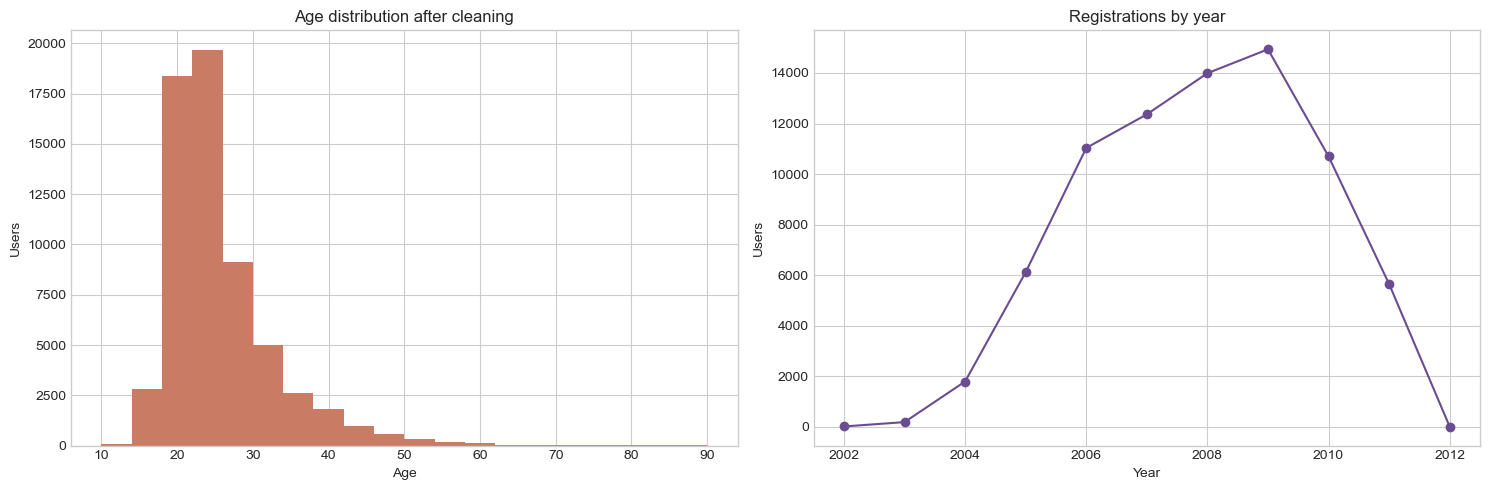

In [7]:
registrations_by_year = (
    users["registered_at"]
    .dt.year
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(users["age_clean"].dropna(), bins=20, color="#c97b63")
axes[0].set_title("Age distribution after cleaning")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Users")

axes[1].plot(registrations_by_year.index, registrations_by_year.values, marker="o", color="#6a4c93")
axes[1].set_title("Registrations by year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Users")

plt.tight_layout()
plt.show()

### Demographic insight

The user base is extremely concentrated in the UK and centered around younger age groups. This matters for the final project because it tells us two things:

- country is usable as a matching feature, but it is not very diverse in this dataset
- age group is likely to be the more discriminating shared trait in the current local data

## 5. Network structure

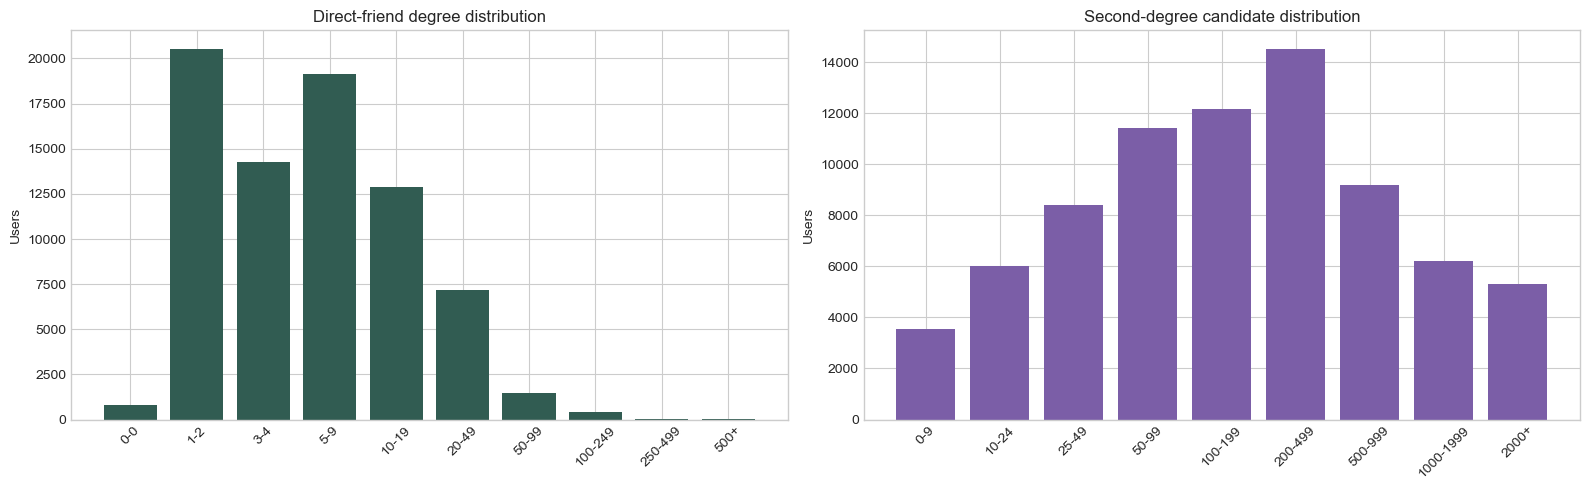

In [8]:
degree_hist = pd.DataFrame(summary["charts"]["degree_histogram"])
second_hist = pd.DataFrame(summary["charts"]["second_degree_histogram"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(degree_hist["label"], degree_hist["value"], color="#315c52")
axes[0].set_title("Direct-friend degree distribution")
axes[0].set_ylabel("Users")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(second_hist["label"], second_hist["value"], color="#7b5ea7")
axes[1].set_title("Second-degree candidate distribution")
axes[1].set_ylabel("Users")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [9]:
top_degree_users = users[["user_id", "degree", "country", "age_group"]].sort_values(
    "degree", ascending=False
).head(15)

display(top_degree_users)

,user_id,degree,country,age_group
5902,5909,2013,UK,10s
51337,51398,1643,UK,20s
41610,41661,1554,UK,20s
46195,46248,1034,UK,40s
70310,70389,924,UK,<NA>
12351,12367,906,UK,50s
50561,50619,801,UK,<NA>
40002,40052,727,UK,<NA>
66358,66434,685,UK,<NA>
3705,3710,618,UK,<NA>


### Network insight

This is the core structural finding for the project:

- the median user has only a modest number of direct friends
- but the second-degree layer expands very quickly

That is exactly why a second-degree explorer makes sense as the main interactive concept.

## 6. Shared-attribute opportunity in the second-degree layer

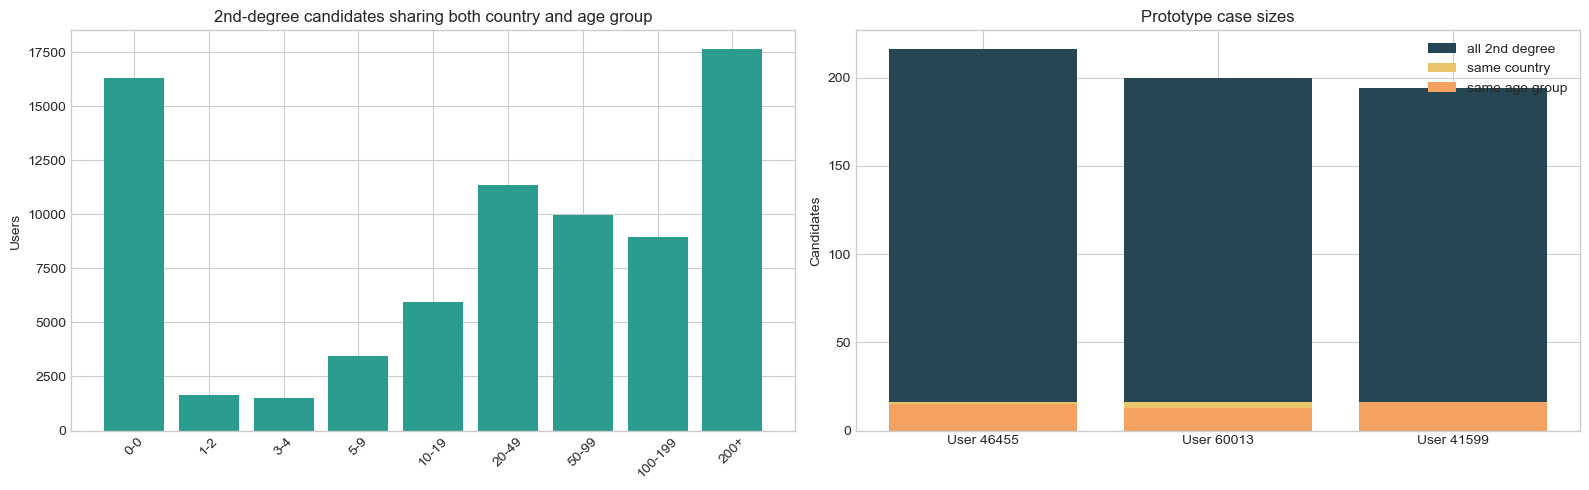

,label,direct_friends,second_degree_count,same_country_second_degree,same_age_group_second_degree
0,User 46455,11,216,16,15
1,User 60013,14,200,16,13
2,User 41599,15,194,16,16


In [10]:
shared_hist = pd.DataFrame(summary["charts"]["shared_attribute_histogram"])
case_sizes = pd.DataFrame(summary["charts"]["prototype_case_sizes"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(shared_hist["label"], shared_hist["value"], color="#2a9d8f")
axes[0].set_title("2nd-degree candidates sharing both country and age group")
axes[0].set_ylabel("Users")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(case_sizes["label"], case_sizes["second_degree_count"], color="#264653", label="all 2nd degree")
axes[1].bar(case_sizes["label"], case_sizes["same_country_second_degree"], color="#e9c46a", label="same country")
axes[1].bar(case_sizes["label"], case_sizes["same_age_group_second_degree"], color="#f4a261", label="same age group")
axes[1].set_title("Prototype case sizes")
axes[1].set_ylabel("Candidates")
axes[1].legend()

plt.tight_layout()
plt.show()

display(case_sizes)

In [11]:
prototype_cases = summary["prototype"]["cases"]

example_tables = []
for case in prototype_cases:
    candidate_table = pd.DataFrame(case["candidates"]).sort_values(
        ["shared_attribute_count", "mutual_friends", "degree"],
        ascending=[False, False, False],
    ).head(8)
    candidate_table.insert(0, "ego_user", case["user"]["id"])
    example_tables.append(candidate_table)

display(pd.concat(example_tables, ignore_index=True))

,ego_user,id,label,country,age_group,degree,mutual_friends,same_country,same_age_group,shared_attribute_count
0,46455,67974,User 67974,UK,20s,24,4,True,True,2
1,46455,44702,User 44702,UK,20s,78,2,True,True,2
2,46455,26989,User 26989,UK,20s,12,2,True,True,2
3,46455,43687,User 43687,UK,20s,10,2,True,True,2
4,46455,73750,User 73750,UK,20s,6,2,True,True,2
5,46455,51398,User 51398,UK,20s,1643,1,True,True,2
6,46455,3670,User 3670,UK,20s,310,1,True,True,2
7,46455,58786,User 58786,UK,20s,252,1,True,True,2
8,60013,10639,User 10639,UK,10s,199,5,True,True,2
9,60013,47859,User 47859,UK,10s,74,3,True,True,2


### Project insight

This section turns the network from a structural picture into a human story. Not every friend-of-a-friend is equally relevant. Filtering by shared age group and shared country produces a smaller subset that is still reachable, but also more socially plausible.

## 7. Tag and artist context

Even though the current local files do not support user-level taste matching, the tag metadata is still worth inspecting because it tells us what the broader Last.fm music language looks like.

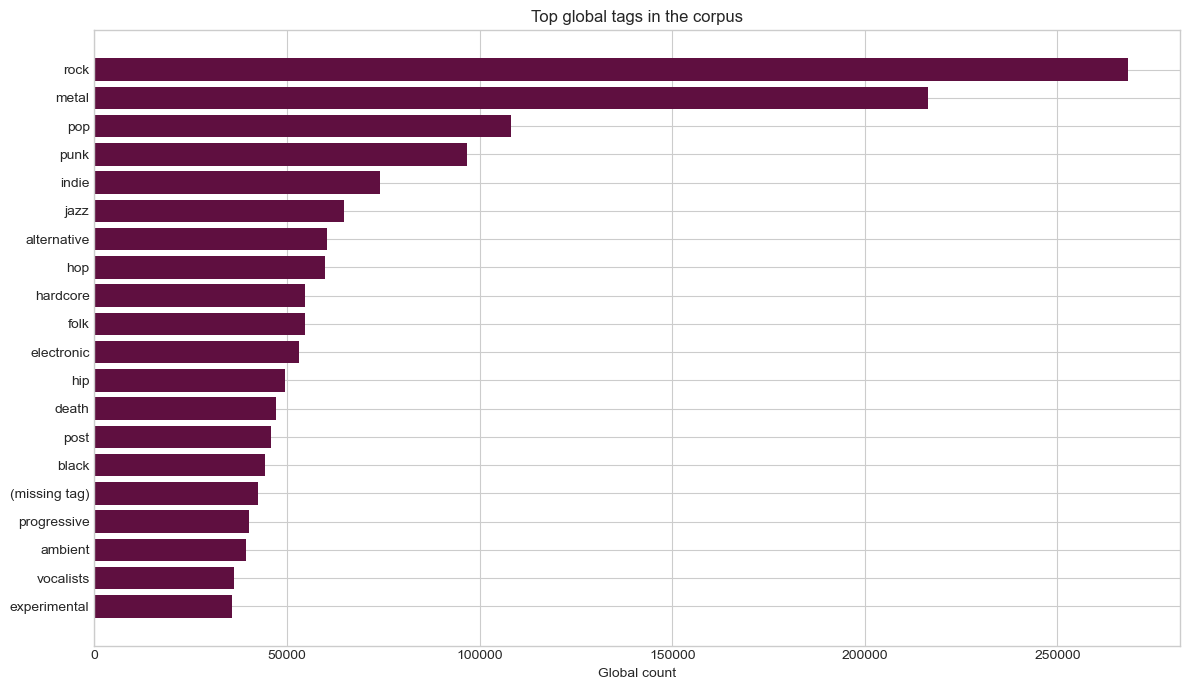

,tag_label,global_count
0,rock,268423
1,metal,216434
2,pop,108098
3,punk,96597
4,indie,74154
5,jazz,64667
6,alternative,60347
7,hop,59829
8,hardcore,54764
9,folk,54534


In [12]:
top_global_tags = tags.sort_values("global_count", ascending=False).head(20).copy()
top_global_tags["tag_label"] = top_global_tags["tag"].fillna("(missing tag)")

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(top_global_tags["tag_label"][::-1], top_global_tags["global_count"][::-1], color="#5f0f40")
ax.set_title("Top global tags in the corpus")
ax.set_xlabel("Global count")
plt.tight_layout()
plt.show()

display(top_global_tags[["tag_label", "global_count"]].head(20))

### Tag insight

The tag space is rich and large, which supports the team's intuition that music taste could become a powerful future matching dimension. The honest limitation is that this notebook can only analyze the tag vocabulary globally, not assign dominant genres to users, because the required user listening table is not present locally.

## 8. Final conclusions

The exploratory analysis supports the project direction strongly.

**What the data clearly supports now**

- a real social graph of explicit friendships
- enough demographic information for matching by age group and country
- strong evidence that second-degree reach is much larger than first-degree reach
- enough structure to build exemplar ego-network cases for a working prototype

**What remains a future extension**

- matching second-degree candidates by user-level music taste

**Bottom line**

The dataset is a good fit for the project. The preprocessing burden is manageable, the graph structure is strong, and the second-degree layer is large enough to justify an interactive visualization centered on meaningful friends-of-friends discovery.

In [13]:
print("Notebook complete. Main Milestone 1 files supporting this analysis:")
print("- music_social_network_eda.ipynb")
print("- milestone1/project_overview.html")
print("- milestone1/eda_second_degree.ipynb")

Notebook complete. Main Milestone 1 files supporting this analysis:
- music_social_network_eda.ipynb
- milestone1/project_overview.html
- milestone1/eda_second_degree.ipynb
